# Chapter 4.3: Sampling Depth and Claim Boundaries

This tutorial isolates the Chapter 4 sampling-depth, WFR-FM sensitivity, stochastic bridge, and claim-boundary audit experiments. It is designed to be read and run from top to bottom without depending on variables from another notebook.

By the end, the notebook has:
- quantified how EB snapshot sampling depth affects normalized state proportions and OT-derived growth proxy diagnostics;
- loaded the precomputed internal WFR-FM sampling-depth sensitivity artifacts, preserving the full-run artifact checks;
- shown a synthetic stochastic bridge as an interpretation boundary rather than EB growth/death evidence;
- written a table-only prior-boundary audit that records which biological priors require external evidence before becoming claims.

The prior-boundary component is a table audit, not a real-data prior experiment. The final manifest section verifies the paper-facing figures, tables, JSON summaries, run config, and split-specific manifest for this notebook.


## 0. Setup

This section makes the notebook independently runnable. It imports dependencies, resolves project paths, selects the device, fixes random seeds, creates output/cache directories, configures plotting, and exposes environment-variable overrides for smoke tests or controlled reruns.

Keep the defaults below as the chapter defaults: figures go to `figures/ch04`, tables and JSON summaries go to `outputs/ch04`, and intermediate caches go to `outputs/ch04/cache` unless `CH04_SMOKE_MODE=1` is set.


The setup is split into four runnable checks: dependency imports and paths, project-local imports, run controls, then output locations and plotting defaults.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch04")

from pathlib import Path
import sys
import json
import math
import time
import random
import hashlib
import warnings
from dataclasses import dataclass
from typing import Callable, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
    from torch import nn
except Exception as exc:
    raise ImportError("Chapter 4 experiments require PyTorch.") from exc

try:
    import anndata as ad
except Exception:
    ad = None

from scipy import sparse
from scipy.sparse.csgraph import shortest_path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:

from src.models import VelocityMLP as ProjectVelocityMLP, count_parameters
from src.losses import cfm_batch, cfm_loss_from_pairs
from src.train import train_cfm_steps
from src.sampling import euler_sample
from src.samplers import CouplingPairSampler as SrcCouplingPairSampler
from src.ot import independent_coupling, coupling_diagnostics
from src.metrics import (
    endpoint_metrics,
    fate_mass_error,
    coupling_l1_distance,
    normalized_cost_matrix,
    distribution_readout_metrics,
)
from src.representations import (
    fit_pca_state_space,
    pca_inverse_transform,
    program_index_dict,
    readout_program_scores_from_matrix,
    standardize_train_space,
)


In [3]:
SEEDS = [42, 43, 44]
DEFAULT_SEED = 42
SOURCE_TIME = "1"
TARGET_TIME = "2"
TRAINING_STEPS = int(os.environ.get("CH04_TRAINING_STEPS", "1500"))
BATCH_SIZE = int(os.environ.get("CH04_BATCH_SIZE", "256"))
DEFAULT_NFE = int(os.environ.get("CH04_DEFAULT_NFE", "64"))
NFE_GRID = [2, 4, 8, 16, 32, 64]
SINKHORN_EPSILON = float(os.environ.get("CH04_SINKHORN_EPSILON", "0.05"))
EPSILON_GRID = [0.01, 0.02, 0.05, 0.1, 0.5]
BOOTSTRAP_REPEATS = int(os.environ.get("CH04_BOOTSTRAP_REPEATS", "50"))
EB_MAX_CELLS_PER_TIME = os.environ.get("CH04_EB_MAX_CELLS_PER_TIME", "")
EB_MAX_CELLS_PER_TIME = None if EB_MAX_CELLS_PER_TIME == "" else int(EB_MAX_CELLS_PER_TIME)
TOY_TRAINING_STEPS = int(os.environ.get("CH04_TOY_TRAINING_STEPS", str(TRAINING_STEPS)))
SMOKE_MODE = os.environ.get("CH04_SMOKE_MODE", "0") == "1"
if SMOKE_MODE:
    TRAINING_STEPS = min(TRAINING_STEPS, 20)
    TOY_TRAINING_STEPS = min(TOY_TRAINING_STEPS, 20)
    BATCH_SIZE = min(BATCH_SIZE, 64)
    DEFAULT_NFE = min(DEFAULT_NFE, 8)
    NFE_GRID = [2, 4, 8]
    BOOTSTRAP_REPEATS = min(BOOTSTRAP_REPEATS, 3)
    EB_MAX_CELLS_PER_TIME = 120 if EB_MAX_CELLS_PER_TIME is None else min(EB_MAX_CELLS_PER_TIME, 120)


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = PROJECT_ROOT / "data"
EB_PATH = DATA_DIR / "trajectorynet_eb" / "eb_velocity_v5.npz"
TOY_DIR = DATA_DIR / "toy_branching_snapshots"
TOY_CSV_PATH = TOY_DIR / "observed_2d_snapshots.csv"
TOY_H5AD_PATH = TOY_DIR / "branching_toy_pseudocounts.h5ad"

FIG_DIR = PROJECT_ROOT /  "figures" / "ch04"
OUT_DIR = PROJECT_ROOT /  "outputs" / "ch04"
if SMOKE_MODE:
    FIG_DIR = FIG_DIR / "smoke"
    OUT_DIR = OUT_DIR / "smoke"
CACHE_DIR = OUT_DIR / "cache"
FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "ch04" / "new3"
for path in [FIG_DIR, OUT_DIR, CACHE_DIR, FINAL_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

PALETTE = {
    "source": "#4C78A8",
    "target": "#F58518",
    "random": "#8E8E8E",
    "ot": "#008A7A",
    "reflow1": "#5369A6",
    "reflow2": "#B279A2",
    "rare": "#D95F02",
    "major": "#2C7FB8",
    "program": "#54A24B",
    "diagnostic": "#E45756",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Training steps: {TRAINING_STEPS}; batch size: {BATCH_SIZE}; default NFE: {DEFAULT_NFE}")
print(f"Smoke mode: {SMOKE_MODE}")

Project root: /home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology
Device: cuda
Training steps: 1500; batch size: 256; default NFE: 64
Smoke mode: False


In [ ]:
from src.utils import set_seed
from src.artifacts import json_ready, load_json, load_npz, load_pt as _load_pt, save_csv, save_json, save_npz, save_pt
from src.artifacts import artifact_exists, as_float32, ensure_finite, sample_rows, stable_hash, to_tensor as _to_tensor


def load_pt(path: str | Path, map_location=None):
    return _load_pt(path, map_location=map_location or DEVICE)


def to_tensor(x, device: torch.device = DEVICE):
    return _to_tensor(x, device)


In [ ]:
from src.ch04_sampling_depth_tutorial import (
    bridge_sampling_diagnostic,
    display_ch04_png,
    display_final_png as _display_final_png,
    load_eb_data as _load_eb_data,
    load_wfrfm_sampling_outputs,
    make_wfrfm_agreement_summary,
    make_wfrfm_growth_delta_grid,
    plot_equal_depth_composition,
    plot_raw_observed_counts,
    plot_sampling_depth_bootstrap_sensitivity,
    plot_stochastic_bridge_demo,
    plot_wfrfm_agreement_summary,
    plot_wfrfm_growth_delta_heatmap,
    remember_source as _remember_source,
    resolve_required_artifact as _resolve_required_artifact,
    safe_relpath as _safe_relpath,
    save_figure as _save_figure,
    save_pub_figure as _save_pub_figure,
    write_claim_boundary_checklist,
    write_final_figure_package,
)

FINAL_SOURCE_PATHS: dict[str, str] = {}

save_figure = lambda fig, filename, close=True: _save_figure(fig, FIG_DIR, filename, close=close)
save_pub_figure = lambda fig, stem, close=True: _save_pub_figure(fig, FINAL_FIG_DIR, stem, close=close)
display_saved_figure = lambda filename: display_ch04_png((FIG_DIR / filename).parent, (FIG_DIR / filename).name) if not Path(filename).is_absolute() else display_ch04_png(Path(filename).parent, Path(filename).name)
display_final_png = lambda stem: _display_final_png(FINAL_FIG_DIR, stem)
safe_relpath = lambda path, root=PROJECT_ROOT: _safe_relpath(path, root)
resolve_required_artifact = lambda filename, preferred_dirs=None: _resolve_required_artifact(filename, preferred_dirs=preferred_dirs or [], search_root=PROJECT_ROOT)
remember_source = lambda name, path: _remember_source(FINAL_SOURCE_PATHS, name, path, root=PROJECT_ROOT)


## 1. Shared Utilities

The utility cells define the shared tutorial machinery used by the EB and toy sections: artifact writers, model wrappers, training/loading helpers, Sinkhorn diagnostics, rollout metrics, and plotting helpers.

The intent is auditability. The key CFM/Sinkhorn/rollout/metric logic stays visible in the notebook, while tested primitives from `src` are reused where available.


The next helper cells keep the scientific machinery readable: model/training wrappers first, then metric diagnostics, then coupling-overlap summaries.

In [ ]:
from src.flow_runtime import make_time_batch, train_cfm as _train_cfm
from src.metrics import mmd_rbf, sliced_w2 as _sliced_w2
from src.ot import compute_cost_matrix, sample_from_plan, sinkhorn_plan
from src.ot import coupling_diagnostics


def sliced_w2(X, Y, n_projections: int = 128, seed: int = DEFAULT_SEED):
    return _sliced_w2(X, Y, n_projections=n_projections, seed=seed)


Rollout wrappers are separate because they are used later for endpoint and path diagnostics after training or loading a model.

In [ ]:
# The 04_3 notebook does not train models; runtime helpers live in src.flow_runtime.


In [ ]:
# Endpoint and path metrics are imported from src.metrics only where this sampling-depth split needs them.


In [ ]:
# Coupling helpers used below are imported from src.ot and src.metrics in the shared utility cell.


In [ ]:
# Generic PHATE pair plotting helpers live in src.ch04_tutorial_plots for the earlier Chapter 4 splits.


In [ ]:
# Generic trajectory, metric-line, heatmap, and table plotting helpers live in src.ch04_tutorial_plots.


## 2. Load EB Data

This section establishes the data contract for all EB experiments in this tutorial.

- Input: `data/eb_velocity_v5.npz`.
- Training and distributional metrics: standardized PC-20, built from `pcs[:, :20]` even though the file stores 100 PCs.
- Display only: two-dimensional `phate` coordinates.
- Main bridge: EB time label `1 -> 2`.
- Artifact: `outputs/ch04/eb_data_summary.json`, which records shapes, labels, standardization, and claim-boundary notes.


Define the EB loader first, then call it in a separate cell so a reader can inspect the snapshot counts before the experiments begin.

In [ ]:
# EB loading lives in src.ch04_sampling_depth_tutorial so this cell stays focused on the tutorial boundary.


In [ ]:
EB = _load_eb_data(
    EB_PATH,
    source_time=SOURCE_TIME,
    target_time=TARGET_TIME,
    out_dir=OUT_DIR,
    max_cells_per_time=EB_MAX_CELLS_PER_TIME,
    seed=DEFAULT_SEED,
)
EB["counts"]


In [ ]:
# Display-only mapping from PC-20 trajectory points back to PHATE for plotting.
from src.ch04_tutorial import fit_pc_to_phate_mapper

pc_to_phate = fit_pc_to_phate_mapper(EB["pcs20_all"], EB["phate_all"], n_neighbors=15)

X0_eb, X1_eb = EB["X0_pc"], EB["X1_pc"]
X0p_eb, X1p_eb = EB["X0_phate"], EB["X1_phate"]
off_manifold_reference_pc = EB["pcs20_all"]
off_manifold_reference_note = "all available EB snapshots in standardized PC-20"
print(off_manifold_reference_note, off_manifold_reference_pc.shape)


## Exp 9. EB Equal-Depth Subsampling

Tutorial goal: separate sampling-depth effects from calibrated biological abundance claims.

This experiment uses all EB time labels. Because the EB snapshots are destructive samples, raw observed cell counts are treated as sampling-depth proxies. If no observed state labels are present, the notebook creates coarse PC-20 state bins only for composition diagnostics. Equal-depth subsampling changes the mass convention to the same sampled depth per time point; it does not establish calibrated abundance, expansion, loss, or state uncertainty.

Start Exp 9 by building coarse diagnostic state bins in standardized PC-20. These are audit bins because the EB file does not provide validated cell-state labels.

In [16]:
labels_all = EB["labels"]
pcs_all = EB["pcs20_all"]
unique_times = sorted(np.unique(labels_all).tolist(), key=lambda s: int(s) if str(s).isdigit() else str(s))
# EB npz has no cell-type/state labels; create coarse bins on PC-20.
n_bins = min(8, max(2, int(np.sqrt(len(unique_times) * 8))))
kmeans = KMeans(n_clusters=n_bins, random_state=42, n_init=10)
state_bins = kmeans.fit_predict(pcs_all).astype(str)
all_bins = sorted(np.unique(state_bins).tolist(), key=lambda s: int(s) if str(s).isdigit() else s)

Next compare the raw destructive snapshot depth with an equal-depth subsample at each time point. The final paper-ready outputs are two independent small figures: raw observed counts and equal-depth composition, both using the same state-bin colors.

In [17]:
counts_rows = []
for t in unique_times:
    mask = labels_all == t
    total = int(mask.sum())
    count_by_bin = pd.Series(state_bins[mask]).value_counts()
    for b in all_bins:
        c = int(count_by_bin.get(b, 0))
        counts_rows.append({"time": t, "state_bin": b, "n_cells": c, "total_time_cells": total, "proportion": float(c / total)})
counts_by_state = pd.DataFrame(counts_rows)

n_min = int(pd.Series(labels_all).value_counts().min())
rng = np.random.default_rng(303)
equal_selected = []
for t in unique_times:
    idx = np.flatnonzero(labels_all == t)
    equal_selected.append(rng.choice(idx, size=n_min, replace=False))
equal_selected = np.concatenate(equal_selected)
equal_rows = []
for t in unique_times:
    idx_t = equal_selected[labels_all[equal_selected] == t]
    count_by_bin = pd.Series(state_bins[idx_t]).value_counts()
    for b in all_bins:
        equal_rows.append({"time": t, "state_bin": b, "n_cells": int(count_by_bin.get(b, 0)), "total_time_cells": int(len(idx_t))})
equal_counts = pd.DataFrame(equal_rows)

In [ ]:
# Final small figures: raw observed EB counts and equal-depth EB composition.
plot_raw_observed_counts(
    counts_by_state,
    unique_times=unique_times,
    all_bins=all_bins,
    final_fig_dir=FINAL_FIG_DIR,
)
plot_equal_depth_composition(
    equal_counts,
    unique_times=unique_times,
    all_bins=all_bins,
    n_min=n_min,
    final_fig_dir=FINAL_FIG_DIR,
)


The bootstrap sweep measures how much the log growth proxy changes when each time point is forced to the same sampling depth.

In [19]:
# Depth-sweep bootstrap counts and log growth proxy.
depth_grid = [d for d in [100, 200, 400, n_min] if d <= n_min]
depth_grid = sorted(set(depth_grid))
bootstrap_count_rows = []
for depth in depth_grid:
    for rep in range(BOOTSTRAP_REPEATS):
        selected = []
        for t in unique_times:
            idx = np.flatnonzero(labels_all == t)
            selected.append(rng.choice(idx, size=depth, replace=False))
        selected = np.concatenate(selected)
        for t in unique_times:
            idx_t = selected[labels_all[selected] == t]
            count_by_bin = pd.Series(state_bins[idx_t]).value_counts()
            for b in all_bins:
                c = int(count_by_bin.get(b, 0))
                bootstrap_count_rows.append({
                    "depth": int(depth), "repeat": int(rep), "time": t, "state_bin": b,
                    "count": c, "proportion": float(c / int(depth)),
                })
boot_counts = pd.DataFrame(bootstrap_count_rows)

In [20]:
eps_growth = 0.5
raw_rows = []
for t0, t1 in zip(unique_times[:-1], unique_times[1:]):
    c0 = counts_by_state[counts_by_state["time"] == t0].set_index("state_bin")
    c1 = counts_by_state[counts_by_state["time"] == t1].set_index("state_bin")
    for b in all_bins:
        n0 = int(c0.loc[b, "n_cells"])
        n1 = int(c1.loc[b, "n_cells"])
        p0 = float(c0.loc[b, "proportion"])
        p1 = float(c1.loc[b, "proportion"])
        raw_rows.append({
            "time_bridge": f"{t0}->{t1}",
            "time_t": t0,
            "time_t_next": t1,
            "state_bin": b,
            "raw_count_t": n0,
            "raw_count_t_next": n1,
            "raw_count_growth_proxy": float(np.log((n1 + eps_growth) / (n0 + eps_growth))),
            "normalized_proportion_change": float(p1 - p0),
        })
raw_growth = pd.DataFrame(raw_rows)

boot_proxy_rows = []
for depth in depth_grid:
    for rep in range(BOOTSTRAP_REPEATS):
        sub = boot_counts[(boot_counts["depth"] == depth) & (boot_counts["repeat"] == rep)]
        for t0, t1 in zip(unique_times[:-1], unique_times[1:]):
            s0 = sub[sub["time"] == t0].set_index("state_bin")
            s1 = sub[sub["time"] == t1].set_index("state_bin")
            for b in all_bins:
                n0 = int(s0.loc[b, "count"])
                n1 = int(s1.loc[b, "count"])
                boot_proxy_rows.append({
                    "depth": int(depth),
                    "repeat": int(rep),
                    "time_bridge": f"{t0}->{t1}",
                    "state_bin": b,
                    "equal_depth_growth_proxy": float(np.log((n1 + eps_growth) / (n0 + eps_growth))),
                })
boot_proxy = pd.DataFrame(boot_proxy_rows)
proxy_summary_all_depths = boot_proxy.groupby(["depth", "time_bridge", "state_bin"]).agg(
    proxy_mean=("equal_depth_growth_proxy", "mean"),
    proxy_ci_low=("equal_depth_growth_proxy", lambda x: float(np.quantile(x, 0.025))),
    proxy_ci_high=("equal_depth_growth_proxy", lambda x: float(np.quantile(x, 0.975))),
).reset_index()
proxy_equal_depth = proxy_summary_all_depths[proxy_summary_all_depths["depth"] == n_min].rename(columns={
    "proxy_mean": "equal_depth_proxy_mean",
    "proxy_ci_low": "equal_depth_proxy_ci_low",
    "proxy_ci_high": "equal_depth_proxy_ci_high",
})

In [21]:
downsampling_table = raw_growth.merge(
    proxy_equal_depth[["time_bridge", "state_bin", "equal_depth_proxy_mean", "equal_depth_proxy_ci_low", "equal_depth_proxy_ci_high"]],
    on=["time_bridge", "state_bin"],
    how="left",
)
ci_width = downsampling_table["equal_depth_proxy_ci_high"] - downsampling_table["equal_depth_proxy_ci_low"]
inside_ci = (downsampling_table["raw_count_growth_proxy"] >= downsampling_table["equal_depth_proxy_ci_low"]) & (downsampling_table["raw_count_growth_proxy"] <= downsampling_table["equal_depth_proxy_ci_high"])
downsampling_table["stable_under_subsampling"] = np.where(inside_ci & (ci_width < 1.0), "stable", "sensitive")
downsampling_table["state_label_source"] = "k-means on standardized PC-20 because EB file has no state/cluster labels"
downsampling_table["abundance_claim_boundary"] = "raw counts reflect sampling depth; not absolute biological abundance"
save_csv(OUT_DIR / "table4_6_eb_downsampling_diagnostics.csv", downsampling_table)
save_csv(CACHE_DIR / "exp9_depth_sweep_growth_proxy.csv", proxy_summary_all_depths)


PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/cache/exp9_depth_sweep_growth_proxy.csv')

The adjacent-bridge diagnostic samples endpoints from balanced OT plans. It remains a PC-20 transport diagnostic, not a trained CFM bridge or a growth model.

In [23]:
bridge_cap = 120 if SMOKE_MODE else 800
bridge_table_path = OUT_DIR / "table4_6b_eb_bridge_sampling_diagnostics.csv"
force_recompute_bridge = os.environ.get("CH04_FORCE_RECOMPUTE_BRIDGE_DIAGNOSTICS", "0") == "1"

if bridge_table_path.exists() and bridge_table_path.stat().st_size > 0 and not force_recompute_bridge:
    bridge_sampling_table = pd.read_csv(bridge_table_path)
else:
    bridge_rows = []
    for bridge_id, (a, b) in enumerate(zip(unique_times[:-1], unique_times[1:])):
        bridge_rows.append(bridge_sampling_diagnostic(
            pcs_all=pcs_all,
            labels_all=labels_all,
            state_bins=state_bins,
            all_bins=all_bins,
            time_a=a,
            time_b=b,
            sampling_setting="original_depth",
            cap=bridge_cap,
            seed=410 + 10 * bridge_id,
            sinkhorn_epsilon=SINKHORN_EPSILON,
        ))
        bridge_rows.append(bridge_sampling_diagnostic(
            pcs_all=pcs_all,
            labels_all=labels_all,
            state_bins=state_bins,
            all_bins=all_bins,
            time_a=a,
            time_b=b,
            sampling_setting="equal_depth",
            cap=min(bridge_cap, n_min),
            seed=411 + 10 * bridge_id,
            sinkhorn_epsilon=SINKHORN_EPSILON,
        ))
    bridge_sampling_table = pd.DataFrame(bridge_rows)
    save_csv(bridge_table_path, bridge_sampling_table)
save_csv(CACHE_DIR / "exp9_adjacent_bridge_ot_sampled_endpoint_diagnostics.csv", bridge_sampling_table)
remember_source("table4_6b_eb_bridge_sampling_diagnostics.csv", bridge_table_path)
bridge_sampling_table

,time_bridge,sampling_setting,n_source,n_target,endpoint_mmd_pc20,sliced_w2_pc20,state_bin_terminal_proportion_error,expected_cost_normalized,effective_support,sinkhorn_converged,diagnostic_type,claim_boundary
0,0->1,original_depth,800,800,0.000318,0.034742,0.008750,0.651583,52318.447634,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
1,0->1,equal_depth,800,800,0.000260,0.033158,0.018750,0.639683,50712.389779,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
2,1->2,original_depth,800,800,0.000339,0.043869,0.028125,0.531669,22941.054524,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
3,1->2,equal_depth,800,800,0.000248,0.034466,0.016875,0.529392,23532.036573,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
4,2->3,original_depth,800,800,0.000237,0.042196,0.023125,0.398269,16550.004814,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
5,2->3,equal_depth,800,800,0.000194,0.035598,0.019375,0.390599,15453.166955,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
6,3->4,original_depth,800,800,0.000306,0.038523,0.013750,0.499373,21657.031657,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...
7,3->4,equal_depth,800,800,0.000256,0.038160,0.011875,0.502330,20608.273555,True,ot_sampled_endpoint_diagnostic_not_trained_cfm,standardized PC-20 OT sampled endpoint diagnos...


In [24]:
boundary_rows = [
    {"assumption": "state labels", "status": "coarse k-means bins used", "claim_boundary": "diagnostic bins, not validated cell types"},
    {"assumption": "cell counts", "status": "observed destructive snapshot counts", "claim_boundary": "sampling depth, not absolute biological abundance"},
    {"assumption": "subsampling", "status": f"equal-depth bootstrap repeats={BOOTSTRAP_REPEATS}", "claim_boundary": "stability diagnostic only"},
    {"assumption": "adjacent bridge OT", "status": "original-depth and equal-depth OT sampled endpoint diagnostics in PC-20", "claim_boundary": "diagnostic only; not trained CFM and not observed paired histories"},
]
boundary_table = pd.DataFrame(boundary_rows)
save_csv(OUT_DIR / "table4_7_biological_assumption_boundary.csv", boundary_table)

PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch04/table4_7_biological_assumption_boundary.csv')

Finally, plot raw-count growth proxies against equal-depth bootstrap intervals. This is a sampling-depth diagnostic and not an abundance calibration: the visual emphasizes which raw proxies fall outside the equal-depth 95% intervals.

In [ ]:
# Final small figure: raw-count proxy versus equal-depth bootstrap intervals.
downsampling_plot_path = remember_source(
    "table4_6_eb_downsampling_diagnostics.csv",
    resolve_required_artifact("table4_6_eb_downsampling_diagnostics.csv", [OUT_DIR]),
)
downsampling_table = pd.read_csv(downsampling_plot_path)
plot_df = plot_sampling_depth_bootstrap_sensitivity(downsampling_table, final_fig_dir=FINAL_FIG_DIR)
plot_df.head()


## Exp 9b. WFR-FM Sampling-Depth Sensitivity

Tutorial goal: load the internal WFR-FM sampling-depth sensitivity outputs and audit how the growth readout changes under raw observed depth versus equal-depth control.

The WFR-FM outputs are read as a mass-convention sensitivity diagnostic. They are not calibrated biological abundance measurements. The final small figures below show only the raw-minus-equal growth heatmap and a compact agreement summary.

In [ ]:
wfrfm_outputs = load_wfrfm_sampling_outputs(
    out_dir=OUT_DIR,
    project_root=PROJECT_ROOT,
    source_paths=FINAL_SOURCE_PATHS,
)
wfrfm_growth_by_bin = wfrfm_outputs.growth_by_bin
wfrfm_sampling_sensitivity = wfrfm_outputs.sampling_sensitivity
wfrfm_summary = wfrfm_outputs.summary

wfrfm_delta = make_wfrfm_growth_delta_grid(wfrfm_growth_by_bin)
plot_wfrfm_growth_delta_heatmap(wfrfm_delta, final_fig_dir=FINAL_FIG_DIR)
wfrfm_agreement_summary = make_wfrfm_agreement_summary(wfrfm_sampling_sensitivity)
plot_wfrfm_agreement_summary(wfrfm_agreement_summary, final_fig_dir=FINAL_FIG_DIR)

print("WFR-FM source summary:")
print({
    "implementation": wfrfm_summary.get("implementation"),
    "output_suffix": wfrfm_summary.get("output_suffix"),
    "epochs": wfrfm_summary.get("epochs"),
    "equal_seeds": wfrfm_summary.get("equal_seeds"),
    "raw_observed_depth_was_capped": wfrfm_summary.get("raw_observed_depth_was_capped"),
})
display(wfrfm_agreement_summary)


## Exp 10. Stochastic Bridge Demo

Tutorial goal: show that stochastic bridge width is a separate path-family assumption from the EB sampling-depth and WFR-FM mass-convention diagnostics.

This is a synthetic normalized demo. The point clouds are not EB observations and are not evidence for calibrated abundance, growth, or state uncertainty.

In [ ]:
bridge_manifest_path = remember_source(
    "cache/exp10_stochastic_bridge_manifest.json",
    resolve_required_artifact("exp10_stochastic_bridge_manifest.json", [CACHE_DIR, OUT_DIR / "cache"]),
)
bridge_manifest = json.loads(bridge_manifest_path.read_text())

_, t_grid_demo = plot_stochastic_bridge_demo(final_fig_dir=FINAL_FIG_DIR)
updated_bridge_manifest = dict(bridge_manifest)
updated_bridge_manifest.update({
    "normalized_mass_per_panel": float(bridge_manifest.get("normalized_mass_per_panel", 1.0)),
    "claim_boundary": "synthetic normalized demo; not EB abundance or growth",
    "displayed_t_grid": t_grid_demo,
    "stochastic_width_note": "wider intermediate distributions under stochastic bridge construction",
})
save_json(CACHE_DIR / "exp10_stochastic_bridge_manifest.json", updated_bridge_manifest)


## Exp 11. Prior Boundary Audit

Tutorial goal: make explicit which biological priors can be used as diagnostics and which claims would require external evidence.

The next cells write `tableA_4_3_prior_boundary_audit.csv` and a small toy marker-strength sanity figure, `figA_4_1_prior_strength_sanity_check.png`. This is a table-only prior audit plus a toy sanity check; it is not a real-data prior experiment.

Claim boundary: any prior would require external evidence before upgrading a diagnostic into a biological claim.


In [28]:
prior_rows = [
    {
        "prior": "RNA velocity alignment",
        "prior_type": "directional transcriptomic prior",
        "injection_point": "loss / diagnostic",
        "external_evidence_required": "validated velocity preprocessing, model assumptions, perturbation or barcoded-history corroboration",
        "allowed_claim": "flow is more aligned with a specified RNA-velocity vector field under stated preprocessing",
        "forbidden_claim": "learned coupling is observed same-cell history or validated developmental outcome",
    },
    {
        "prior": "marker monotonicity",
        "prior_type": "marker trend constraint",
        "injection_point": "loss / readout / diagnostic",
        "external_evidence_required": "curated marker set and expected direction from independent biology",
        "allowed_claim": "generated trajectories respect the specified marker monotonicity prior",
        "forbidden_claim": "marker prior proves true temporal ordering without external validation",
    },
    {
        "prior": "cell-type labels",
        "prior_type": "categorical annotation prior",
        "injection_point": "sampling / readout / diagnostic",
        "external_evidence_required": "validated annotation protocol and uncertainty handling",
        "allowed_claim": "terminal label proportions or forbidden transitions under provided labels",
        "forbidden_claim": "labels create same-cell histories",
    },
    {
        "prior": "barcoded history assays",
        "prior_type": "external paired-history evidence",
        "injection_point": "loss / sampling / evaluation",
        "external_evidence_required": "barcode assay with group calling and sampling bias model",
        "allowed_claim": "agreement with barcode-derived constraints",
        "forbidden_claim": "unobserved transitions are recovered without barcode coverage",
    },
    {
        "prior": "GRN constraints",
        "prior_type": "mechanistic regulatory prior",
        "injection_point": "loss / diagnostic",
        "external_evidence_required": "GRN source, confidence scores, cell-context validation",
        "allowed_claim": "flow is consistent with selected GRN constraints under the chosen model",
        "forbidden_claim": "GRN-constrained flow proves causal regulation by itself",
    },
]
prior_audit = pd.DataFrame(prior_rows)
save_csv(OUT_DIR / "tableA_4_3_prior_boundary_audit.csv", prior_audit)
prior_audit


,prior,prior_type,injection_point,external_evidence_required,allowed_claim,forbidden_claim
0,RNA velocity alignment,directional transcriptomic prior,loss / diagnostic,"validated velocity preprocessing, model assump...",flow is more aligned with a specified RNA-velo...,learned coupling is observed same-cell history...
1,marker monotonicity,marker trend constraint,loss / readout / diagnostic,curated marker set and expected direction from...,generated trajectories respect the specified m...,marker prior proves true temporal ordering wit...
2,cell-type labels,categorical annotation prior,sampling / readout / diagnostic,validated annotation protocol and uncertainty ...,terminal label proportions or forbidden transi...,labels create same-cell histories
3,barcoded history assays,external paired-history evidence,loss / sampling / evaluation,barcode assay with group calling and sampling ...,agreement with barcode-derived constraints,unobserved transitions are recovered without b...
4,GRN constraints,mechanistic regulatory prior,loss / diagnostic,"GRN source, confidence scores, cell-context va...",flow is consistent with selected GRN constrain...,GRN-constrained flow proves causal regulation ...


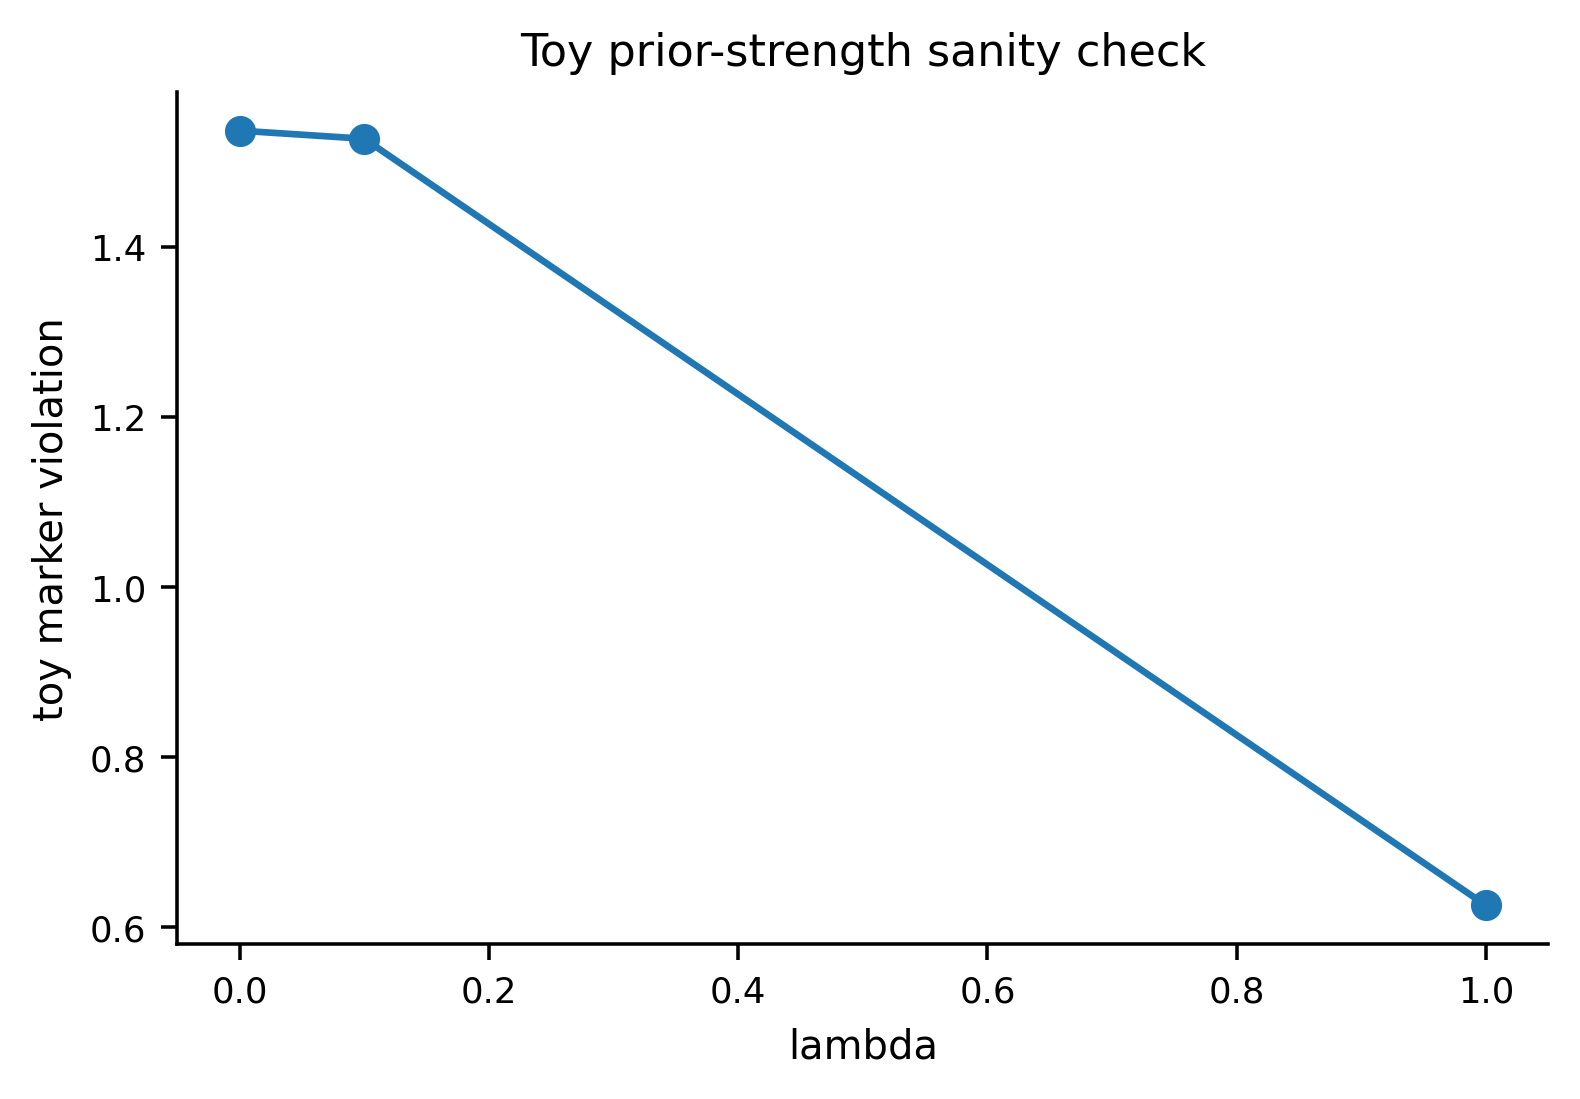

,lambda,monotonicity_violation_sum
0,0.0,1.536948
1,0.1,1.527401
2,1.0,0.625742


In [29]:
# Optional small toy marker monotonicity sanity check.
lambdas = [0, 0.1, 1.0]
marker_rows = []
for lam in lambdas:
    vals = np.linspace(0, 1, 50) + np.random.default_rng(int(lam * 100 + 5)).normal(scale=0.08 / (1 + lam), size=50)
    violations = np.maximum(0, -np.diff(vals)).sum()
    marker_rows.append({"lambda": lam, "monotonicity_violation_sum": float(violations)})
marker_table = pd.DataFrame(marker_rows)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(marker_table["lambda"], marker_table["monotonicity_violation_sum"], marker="o")
ax.set_xlabel("lambda")
ax.set_ylabel("toy marker violation")
ax.set_title("Toy prior-strength sanity check")
save_figure(fig, "figA_4_1_prior_strength_sanity_check.png")
display_saved_figure("figA_4_1_prior_strength_sanity_check.png")
marker_table

## Artifact Manifest

This final section writes the standalone `figures/ch04/new3/` package, records the source tables/json used, and checks that every required PNG/PDF/SVG exists. The claim boundary remains narrow: sampling-depth proxy, equal-depth mass convention, mass-convention sensitivity of growth readouts, and a separate synthetic normalized bridge-width demo.


In [ ]:
# Expected artifact names are declared in the manifest cell below so tests and readers audit the same cell.


In [ ]:
source_paths = {
    "table4_6_eb_downsampling_diagnostics.csv": remember_source(
        "table4_6_eb_downsampling_diagnostics.csv",
        resolve_required_artifact("table4_6_eb_downsampling_diagnostics.csv", [OUT_DIR]),
    ),
    "table4_6b_eb_bridge_sampling_diagnostics.csv": remember_source(
        "table4_6b_eb_bridge_sampling_diagnostics.csv",
        resolve_required_artifact("table4_6b_eb_bridge_sampling_diagnostics.csv", [OUT_DIR]),
    ),
    "table4_6c_wfrfm_growth_by_bin_full.csv": remember_source(
        "table4_6c_wfrfm_growth_by_bin_full.csv",
        resolve_required_artifact("table4_6c_wfrfm_growth_by_bin_full.csv", [OUT_DIR]),
    ),
    "table4_6d_wfrfm_sampling_sensitivity_full.csv": remember_source(
        "table4_6d_wfrfm_sampling_sensitivity_full.csv",
        resolve_required_artifact("table4_6d_wfrfm_sampling_sensitivity_full.csv", [OUT_DIR]),
    ),
    "wfrfm_sampling_sensitivity_summary_full.json": remember_source(
        "wfrfm_sampling_sensitivity_summary_full.json",
        resolve_required_artifact("wfrfm_sampling_sensitivity_summary_full.json", [OUT_DIR]),
    ),
    "cache/exp10_stochastic_bridge_manifest.json": remember_source(
        "cache/exp10_stochastic_bridge_manifest.json",
        resolve_required_artifact("exp10_stochastic_bridge_manifest.json", [CACHE_DIR, OUT_DIR / "cache"]),
    ),
}

expected_figures = [
    "fig4_11a_eb_observed_counts.png",
    "fig4_11b_sampling_depth_sensitivity.png",
    "fig4_11c_stochastic_bridge_demo.png",
    "figA_4_1_prior_strength_sanity_check.png",
    "fig4_11d_wfrfm_growth_sensitivity_full.png",
]
expected_tables = [
    "table4_6_eb_downsampling_diagnostics.csv",
    "table4_6b_eb_bridge_sampling_diagnostics.csv",
    "table4_6c_wfrfm_growth_by_bin_full.csv",
    "table4_6d_wfrfm_sampling_sensitivity_full.csv",
    "wfrfm_sampling_sensitivity_summary_full.json",
    "tableA_4_3_prior_boundary_audit.csv",
]
required_paths = list(source_paths.values())
if any(not Path(path).exists() for path in required_paths):
    raise FileNotFoundError("Missing required source artifact for 04_3 final QA")

run_config = {
    "SMOKE_MODE": bool(SMOKE_MODE),
    "TRAINING_STEPS": int(TRAINING_STEPS),
    "BATCH_SIZE": int(BATCH_SIZE),
    "DEFAULT_NFE": int(DEFAULT_NFE),
    "DEVICE": str(DEVICE),
    "final_figure_dir": safe_relpath(FINAL_FIG_DIR),
}
save_json(OUT_DIR / "run_config_04_3_sampling_depth_and_claim_boundaries.json", run_config)
checklist_table = write_claim_boundary_checklist(OUT_DIR)
package = write_final_figure_package(
    project_root=PROJECT_ROOT,
    final_fig_dir=FINAL_FIG_DIR,
    source_paths=source_paths,
    final_source_paths=FINAL_SOURCE_PATHS,
)

print("Final figure directory:", safe_relpath(FINAL_FIG_DIR))
print("Source files used:", ", ".join(sorted(FINAL_SOURCE_PATHS.values())))
artifact_manifest_path = OUT_DIR / "artifact_manifest_04_3_sampling_depth_and_claim_boundaries.csv"
save_csv(artifact_manifest_path, package.manifest)

display(package.qa_table)
display(package.manifest)
